In [15]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Statevector, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit_aer.noise import PauliLindbladError

# pec.py 必須和 notebook 放在同一個資料夾
module_dir = Path.cwd()

if not (module_dir / "pec.py").exists():
    raise FileNotFoundError(
        "找不到 pec.py。請把 pec.py 放在這份 notebook 的同一個資料夾。"
    )

if str(module_dir) not in sys.path:
    sys.path.insert(0, str(module_dir))

import pec as pec_module
from pec import PEC

print("PEC module loaded from:", pec_module.__file__)

PEC module loaded from: C:\Users\alber\大專生ipython\PEC_4Q_GHZ_import_test_bundle\pec.py


{'0100': 66, '1101': 58, '1100': 70, '0000': 60, '0111': 71, '0101': 52, '1111': 73, '1011': 60, '0010': 65, '0001': 74, '1010': 66, '0110': 67, '1110': 50, '1000': 61, '1001': 74, '0011': 57}


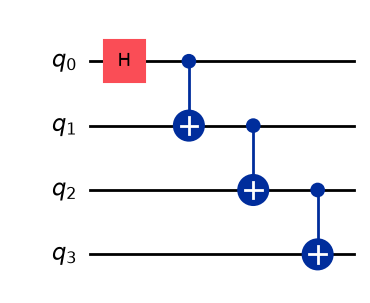

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Pauli, Statevector, DensityMatrix
from qiskit_aer import AerSimulator
from qiskit.circuit import Gate
from qiskit_aer.noise import NoiseModel, depolarizing_error


qubits = 4
qc = QuantumCircuit(qubits)
qc.h(0)
for i in range(qubits-1):
    qc.cx(i, i+1)


p_1qubit = 0.20
p_2qubit = 0.

error_h = depolarizing_error(p_1qubit, 1)
error_cx = depolarizing_error(p_2qubit, 2)

noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(error_h, ['h'])    # 套用到所有 h gate
noise_model.add_all_qubit_quantum_error(error_cx, ['cx'])  # 套用到所有 cx gate


sim_noise = AerSimulator(noise_model=noise_model)

qc_meas = qc.copy()
qc_meas.measure_all()

shots = 1024
result = sim_noise.run(qc_meas, shots=shots).result()
counts = result.get_counts()

print(counts)

# 繪製電路圖
qc.draw("mpl") 

In [31]:
import time
import warnings


# ============================================================
# 1. PEC 使用的目標電路
# ============================================================

# 注意：
# qc.copy() 只複製量子閘，不會複製 noise_model
noise_circuit = qc.copy()


# ============================================================
# 2. 建立 PEC 物件
# ============================================================

# PEC 初始化時尚未收到 noisy backend，
# 因此可能先發出「預設 AerSimulator 是 ideal」的警告。
# 這裡只隱藏初始化階段的警告，後面仍會真正指定 noisy backend。
with warnings.catch_warnings():

    warnings.filterwarnings(
        "ignore",
        message=r"No explicit trailing noise channel.*",
        category=RuntimeWarning,
    )

    myPEC = PEC(
        noise_circuit,
        repeat=10,
        seed=412220419,
        shots=2048,
        observable="XXXX",
    )


# ============================================================
# 3. 重要：將 noisy AerSimulator 傳入 PEC
# ============================================================

# sim_noise 已在前一格定義：
# sim_noise = AerSimulator(noise_model=noise_model)

myPEC.set_backend(sim_noise)

print("PEC object created successfully.")
print("Noisy backend assigned successfully.")

print("\nNoise instructions:")
print(noise_model.noise_instructions)


# ============================================================
# 4. 檢查 PEC noise basis
# ============================================================

print("\nNumber of qubits:", myPEC.n_qubits)
print("Neighbor edges:", myPEC.neighbor_edges())
print("Number of noise terms:", len(myPEC.noise_basis()))

basis_df = pd.DataFrame({
    "k": np.arange(len(myPEC.noise_basis())),
    "Pauli term": myPEC.noise_basis(),
})

display(basis_df)


# ============================================================
# 5. 使用 noisy backend 學習 noise rates
# ============================================================

fit_start = time.perf_counter()

learned_noise_df = myPEC.fit()

fit_time = time.perf_counter() - fit_start

print(f"\nNoise-learning time: {fit_time:.3f} s")
display(learned_noise_df)


# ============================================================
# 6. 顯示 PEC 結果
# ============================================================

print("\nPEC overhead gamma =", myPEC.overhead())

print("\nOverhead details:")
print(myPEC.overhead(details=True))

print("\nActive inverse-QPD terms:")
display(myPEC.qpd_terms())

PEC object created successfully.
Noisy backend assigned successfully.

Noise instructions:
['cx', 'h']

Number of qubits: 4
Neighbor edges: [(0, 1), (1, 2), (2, 3)]
Number of noise terms: 39


,k,Pauli term
0,0,IIIX
1,1,IIIY
2,2,IIIZ
3,3,IIXI
4,4,IIYI
5,5,IIZI
6,6,IXII
7,7,IYII
8,8,IZII
9,9,XIII



Noise-learning time: 2.255 s


,Pauli term,lambda,active,p_identity,p_pauli
0,IIIX,0.000000,False,1.000000,0.000000
1,IIIY,0.000000,False,1.000000,0.000000
2,IIIZ,0.135801,True,0.881079,0.118921
3,IIXI,0.000000,False,1.000000,0.000000
4,IIYI,0.000000,False,1.000000,0.000000
5,IIZI,0.000000,False,1.000000,0.000000
6,IXII,0.000000,False,1.000000,0.000000
7,IYII,0.000000,False,1.000000,0.000000
8,IZII,0.000000,False,1.000000,0.000000
9,XIII,0.345021,True,0.750778,0.249222



PEC overhead gamma = 236.50796298540922

Overhead details:
{'gamma': 236.50796298540922, 'sampling_cost_factor': 55936.0165555077, 'active_qpd_terms': 7}

Active inverse-QPD terms:


,pauli,lambda,p_identity,p_pauli
0,IIIZ,0.135801,0.881079,0.118921
1,XIII,0.345021,0.750778,0.249222
2,IIZX,0.402079,0.723732,0.276268
3,IIZZ,0.229897,0.815707,0.184293
4,XXII,1.299589,0.537167,0.462833
5,ZXII,0.047007,0.955135,0.044865
6,YZII,0.273597,0.789286,0.210714


In [32]:
print("PEC overhead gamma =", myPEC.overhead())
print()
print("Overhead details:")
print(myPEC.overhead(details=True))

print()
print("Active inverse-QPD terms:")
display(myPEC.qpd_terms())

PEC overhead gamma = 236.50796298540922

Overhead details:
{'gamma': 236.50796298540922, 'sampling_cost_factor': 55936.0165555077, 'active_qpd_terms': 7}

Active inverse-QPD terms:


,pauli,lambda,p_identity,p_pauli
0,IIIZ,0.135801,0.881079,0.118921
1,XIII,0.345021,0.750778,0.249222
2,IIZX,0.402079,0.723732,0.276268
3,IIZZ,0.229897,0.815707,0.184293
4,XXII,1.299589,0.537167,0.462833
5,ZXII,0.047007,0.955135,0.044865
6,YZII,0.273597,0.789286,0.210714
